In [16]:
import os
import time
import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
import xgboost as xgb

# ============================================================
# Imports
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import torch

In [17]:
RANDOM_STATE = 42
BATCH_SIZE = 16

SPLIT_FILE = "data/processed_features/fixed_split_indices.npz"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [18]:

# ============================================================
# 2. LOAD CURATED BINDINGDB FEATURES
# ============================================================

X_lig = np.load(
    "data/processed_features/X_lig.npy",
    mmap_mode="r"
)

X_prot = np.load(
    "data/processed_features/X_prot.npy",
    mmap_mode="r"
)

y = np.load(
    "data/processed_features/y.npy",
    mmap_mode="r"
)

print("\nDataset:")
print("Ligand shape :", X_lig.shape)
print("Protein shape:", X_prot.shape)
print("Target shape :", y.shape)


Dataset:
Ligand shape : (148111, 1024)
Protein shape: (148111, 320)
Target shape : (148111,)


In [19]:
# ------------------------------------------------------------
# Check alignment
# ------------------------------------------------------------

assert len(X_lig) == len(X_prot) == len(y), (
    "Ligand, protein and target arrays are not aligned."
)

N = len(y)

print("Total samples:", N)

Total samples: 148111


In [ ]:
# ============================================================
# 3. CREATE FIXED INDICES
# ============================================================
#
# IMPORTANT:
# We split INDICES rather than X_lig, X_prot and y directly.
#
# This means exactly the same observations can be supplied to
# every machine-learning and deep-learning model.
#
# Final split:
#
# Training   = 64%
# Validation = 16%
# Test       = 20%
#
# ============================================================

if os.path.exists(SPLIT_FILE):

    print("\nLoading existing fixed split...")

    split_data = np.load(SPLIT_FILE)

    train_idx = split_data["train_idx"]
    val_idx = split_data["val_idx"]
    test_idx = split_data["test_idx"]

else:

    print("\nCreating fixed split...")

    all_indices = np.arange(N)

    # --------------------------------------------------------
    # 80% development / 20% test
    # --------------------------------------------------------

    train_val_idx, test_idx = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # --------------------------------------------------------
    # 80% of development = training
    # 20% of development = validation
    #
    # Overall:
    # training   = 64%
    # validation = 16%
    # test       = 20%
    # --------------------------------------------------------

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    os.makedirs(
        os.path.dirname(SPLIT_FILE),
        exist_ok=True
    )

    np.savez(
        SPLIT_FILE,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx
    )

    print("Fixed split saved to:")
    print(SPLIT_FILE)



Loading existing fixed split...


In [21]:

# ============================================================
# 4. VERIFY FIXED SPLITS
# ============================================================

print("\nFinal dataset partition:")
print("Training samples  :", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples      :", len(test_idx))


Final dataset partition:
Training samples  : 94790
Validation samples: 23698
Test samples      : 29623


In [22]:


# ------------------------------------------------------------
# Verify that no sample appears in multiple partitions
# ------------------------------------------------------------

assert len(
    np.intersect1d(train_idx, val_idx)
) == 0, "Train/validation overlap detected."

assert len(
    np.intersect1d(train_idx, test_idx)
) == 0, "Train/test overlap detected."

assert len(
    np.intersect1d(val_idx, test_idx)
) == 0, "Validation/test overlap detected."

assert (
    len(train_idx) +
    len(val_idx) +
    len(test_idx)
) == N, "Split sizes do not match dataset size."

print("\nSplit verification: PASSED")



Split verification: PASSED


In [23]:

# ============================================================
# 5. APPLY EXACT SAME INDICES TO ALL DATA
# ============================================================

Xl_train = X_lig[train_idx]
Xl_val = X_lig[val_idx]
Xl_test = X_lig[test_idx]

Xp_train = X_prot[train_idx]
Xp_val = X_prot[val_idx]
Xp_test = X_prot[test_idx]

y_train = np.asarray(y[train_idx]).ravel()
y_val = np.asarray(y[val_idx]).ravel()
y_test = np.asarray(y[test_idx]).ravel()

In [24]:
print("\ny_test shape:", y_test.shape)


y_test shape: (29623,)


In [25]:
# ============================================================
# 6. PREPARE FEATURES FOR CONVENTIONAL ML MODELS
# ============================================================
#
# Ridge, Random Forest and XGBoost require a single feature
# matrix.
#
# Therefore ligand and protein representations are concatenated.
#
# Deep learning can continue receiving ligand and protein
# inputs separately.
# ============================================================

# Flatten protein features if necessary
if Xp_train.ndim > 2:

    Xp_train_ml = Xp_train.reshape(len(Xp_train), -1)
    Xp_val_ml = Xp_val.reshape(len(Xp_val), -1)
    Xp_test_ml = Xp_test.reshape(len(Xp_test), -1)

else:

    Xp_train_ml = Xp_train
    Xp_val_ml = Xp_val
    Xp_test_ml = Xp_test


X_train_ml = np.concatenate(
    [Xl_train, Xp_train_ml],
    axis=1
).astype(np.float32)

X_val_ml = np.concatenate(
    [Xl_val, Xp_val_ml],
    axis=1
).astype(np.float32)

X_test_ml = np.concatenate(
    [Xl_test, Xp_test_ml],
    axis=1
).astype(np.float32)

print("\nConventional ML feature shapes:")
print("Train:", X_train_ml.shape)
print("Val  :", X_val_ml.shape)
print("Test :", X_test_ml.shape)


Conventional ML feature shapes:
Train: (94790, 1344)
Val  : (23698, 1344)
Test : (29623, 1344)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
y_train = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.reshape(-1, 1)).flatten()

In [27]:

# ============================================================
# Utility Functions
# ============================================================

def predict_in_batches(
    model,
    X,
    batch_size=BATCH_SIZE
):
    """
    Predict in smaller batches to reduce peak memory usage.
    """

    predictions = []

    for start_index in range(0, len(X), batch_size):
        end_index = min(
            start_index + batch_size,
            len(X)
        )

        batch_predictions = model.predict(
            X[start_index:end_index]
        )

        predictions.append(
            np.asarray(
                batch_predictions,
                dtype=np.float32
            ).ravel()
        )

    return np.concatenate(predictions)


In [28]:

def train_and_evaluate(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    evaluator
):
    """
    Train and evaluate a standard scikit-learn-compatible model.
    """

    print(f"\nTraining {model_name}...")

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    predictions = predict_in_batches(
        model,
        X_test
    )
    inference_time = time.perf_counter() - start_time

    evaluator.evaluate(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        train_time=train_time,
        inference_time=inference_time
    )

    return model

In [29]:
from lifelines.utils import concordance_index

# ============================================================
# Output paths
# ============================================================

RESULTS_FILE = "results/baseline_model_results.csv"
PLOT_DIR = "results/plots"

os.makedirs(PLOT_DIR, exist_ok=True)


# ============================================================
# Evaluation
# ============================================================

class ModelEvaluator:

    def __init__(self):
        self.results = []


    # --------------------------------------------------------
    # Evaluate a single model
    # --------------------------------------------------------

    def evaluate(
        self,
        model_name,
        y_true,
        y_pred,
        train_time,
        inference_time
    ):
        """
        Calculate regression metrics and store the results.
        """

        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()

        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).ravel()
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        c_index = concordance_index(y_true, y_pred)

        # Pearson correlation is undefined for constant arrays
        if (
            len(y_true) > 1
            and np.std(y_true) > 0
            and np.std(y_pred) > 0
        ):
            pearson_corr, _ = pearsonr(y_true, y_pred)
        else:
            pearson_corr = 0.0
        
        

        result = {
            "Model": model_name,
            "MSE": float(mse),
            "RMSE": float(rmse),
            "MAE": float(mae),
            "R2_Score": float(r2),
            "Pearson_Correlation": float(pearson_corr),
            "Train_Time_sec": float(train_time),
            "Inference_Time_sec": float(inference_time),
            "Concordance_Index": float(c_index)
        }

        self.results.append(result)

        print(f"\n--- {model_name} Evaluation ---")

        print(
            f"MSE: {mse:.4f} | "
            f"RMSE: {rmse:.4f} | "
            f"MAE: {mae:.4f} | "
            f"Concordance Index: {c_index:.4f}"
        )

        print(
            f"R²: {r2:.4f} | "
            f"Pearson: {pearson_corr:.4f}"
        )

        print(
            f"Train time: {train_time:.2f}s | "
            f"Inference time: {inference_time:.4f}s"
        )


    # --------------------------------------------------------
    # Results dataframe
    # --------------------------------------------------------

    def get_results_dataframe(self):
        """
        Return model results ordered by RMSE.
        Lower RMSE indicates better performance.
        """

        if not self.results:
            return pd.DataFrame()

        return (
            pd.DataFrame(self.results)
            .sort_values(by="RMSE", ascending=True)
            .reset_index(drop=True)
        )


    # --------------------------------------------------------
    # Print summary table
    # --------------------------------------------------------

    def print_summary(self):

        results_df = self.get_results_dataframe()

        if results_df.empty:
            print("No model results are available.")
            return

        print("\n" + "=" * 120)
        print("BASELINE MODEL PERFORMANCE COMPARISON")
        print("=" * 120)

        display_df = results_df.copy()

        numeric_columns = display_df.select_dtypes(
            include=[np.number]
        ).columns

        display_df[numeric_columns] = (
            display_df[numeric_columns].round(4)
        )

        print(display_df.to_string(index=False))


    # --------------------------------------------------------
    # Save results to CSV
    # --------------------------------------------------------

    def save_to_csv(self, filepath=RESULTS_FILE):
        """
        Save all accumulated model results to CSV.
        """

        results_df = self.get_results_dataframe()

        if results_df.empty:
            print("No results to save.")
            return

        output_directory = os.path.dirname(filepath)

        if output_directory:
            os.makedirs(output_directory, exist_ok=True)

        results_df.to_csv(filepath, index=False)

        print(
            f"\nResults successfully saved to: {filepath}"
        )


    # ========================================================
    # Plot 1: Error metrics
    # ========================================================

    def plot_error_metrics(
        self,
        save_path=None
    ):
        """
        Compare MSE, RMSE and MAE across baseline models.
        Lower values indicate better performance.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        metrics = ["MSE", "RMSE", "MAE"]

        x = np.arange(len(df))
        width = 0.25

        fig, ax = plt.subplots(figsize=(12, 6))

        for i, metric in enumerate(metrics):

            bars = ax.bar(
                x + (i - 1) * width,
                df[metric],
                width,
                label=metric
            )

            ax.bar_label(
                bars,
                fmt="%.3f",
                padding=3,
                fontsize=8
            )

        ax.set_xlabel("Model")
        ax.set_ylabel("Error")
        ax.set_title(
            "Baseline Model Error Metrics Comparison"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            df["Model"],
            rotation=20,
            ha="right"
        )

        ax.legend()

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_error_metrics.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Plot 2: R²
    # ========================================================

    def plot_r2(
        self,
        save_path=None
    ):
        """
        Plot R² score for each baseline model.
        Higher values indicate better performance.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["R2_Score"]
        )

        ax.bar_label(
            bars,
            fmt="%.3f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("R² Score")
        ax.set_title(
            "Baseline Model R² Score Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_r2_scores.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Plot 3: Pearson correlation
    # ========================================================

    def plot_pearson(
        self,
        save_path=None
    ):
        """
        Plot Pearson correlation.
        Higher values indicate stronger linear agreement.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Pearson_Correlation"]
        )

        ax.bar_label(
            bars,
            fmt="%.3f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Pearson Correlation")
        ax.set_title(
            "Baseline Model Pearson Correlation Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_pearson_correlation.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Plot 4: Training time
    # ========================================================

    def plot_training_time(
        self,
        save_path=None
    ):
        """
        Compare model training times.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Train_Time_sec"]
        )

        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Training Time (seconds)")
        ax.set_title(
            "Baseline Model Training Time Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_training_time.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Plot 5: Inference time
    # ========================================================

    def plot_inference_time(
        self,
        save_path=None
    ):
        """
        Compare model inference times.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Inference_Time_sec"]
        )

        ax.bar_label(
            bars,
            fmt="%.4f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Inference Time (seconds)")
        ax.set_title(
            "Baseline Model Inference Time Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_inference_time.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Generate comparison table as image
    # ========================================================

    def plot_results_table(
        self,
        save_path=None
    ):
        """
        Generate a model comparison table and save as an image.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for table.")
            return

        display_df = df.copy()

        # Shorter column names for dissertation table
        display_df = display_df.rename(
            columns={
                "R2_Score": "R²",
                "Pearson_Correlation": "Pearson",
                "Train_Time_sec": "Train Time (s)",
                "Inference_Time_sec": "Inference Time (s)"
            }
        )

        # Round values
        columns_4dp = [
            "MSE",
            "RMSE",
            "MAE",
            "R²",
            "Pearson",
            "Inference Time (s)"
        ]

        for col in columns_4dp:
            display_df[col] = display_df[col].map(
                lambda x: f"{x:.4f}"
            )

        display_df["Train Time (s)"] = (
            display_df["Train Time (s)"]
            .map(lambda x: f"{x:.2f}")
        )

        fig_height = max(
            2.5,
            0.6 * len(display_df) + 1.5
        )

        fig, ax = plt.subplots(
            figsize=(15, fig_height)
        )

        ax.axis("off")

        table = ax.table(
            cellText=display_df.values,
            colLabels=display_df.columns,
            cellLoc="center",
            loc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.6)

        ax.set_title(
            "Baseline Model Performance Comparison",
            fontsize=14,
            pad=20
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_results_table.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    # ========================================================
    # Generate everything
    # ========================================================

    def generate_report(self):
        """
        Print table, save CSV, and generate all baseline plots.
        """

        self.print_summary()

        self.save_to_csv()

        self.plot_error_metrics()

        self.plot_r2()

        self.plot_pearson()

        self.plot_training_time()

        self.plot_inference_time()

        self.plot_results_table()

DRUG-TARGET AFFINITY BASELINE EXPERIMENT

Dataset partitions
----------------------------------------
Train      : 94,790
Validation : 23,698
Test       : 29,623
Features   : 1,344

1. Mean Baseline

Training Mean Baseline...

--- Mean Baseline Evaluation ---
MSE: 2.0776 | RMSE: 1.4414 | MAE: 1.1614 | Concordance Index: 0.5000
R²: -0.0000 | Pearson: nan
Train time: 0.00s | Inference time: 0.0066s

2. Ridge Regression

Selecting Ridge alpha using validation set...


/var/folders/v_/c443zsfs6r1cp977xnzq125m0000gn/T/ipykernel_77371/1508903438.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, _ = pearsonr(y_true, y_pred)


alpha=0.01    Validation RMSE=0.8514
alpha=0.1     Validation RMSE=0.8514
alpha=1.0     Validation RMSE=0.8514
alpha=10.0    Validation RMSE=0.8514
alpha=100.0   Validation RMSE=0.8515

Best Ridge alpha: 1.0
Best validation RMSE: 0.8514

Training Ridge Regression...

--- Ridge Regression Evaluation ---
MSE: 1.5102 | RMSE: 1.2289 | MAE: 0.9727 | Concordance Index: 0.6770
R²: 0.2731 | Pearson: 0.5229
Train time: 2.35s | Inference time: 0.1845s

3. Random Forest

Selecting Random Forest parameters using validation set...
{'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.2} -> RMSE=0.7946
{'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.2} -> RMSE=0.7426
{'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 0.3} -> RMSE=0.7125
{'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.2} -> RMSE=0.6840

Best RF parameters: {'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.2}
Best validation RMSE: 0.6840

Training Random Forest...

--- Random Forest Evalua

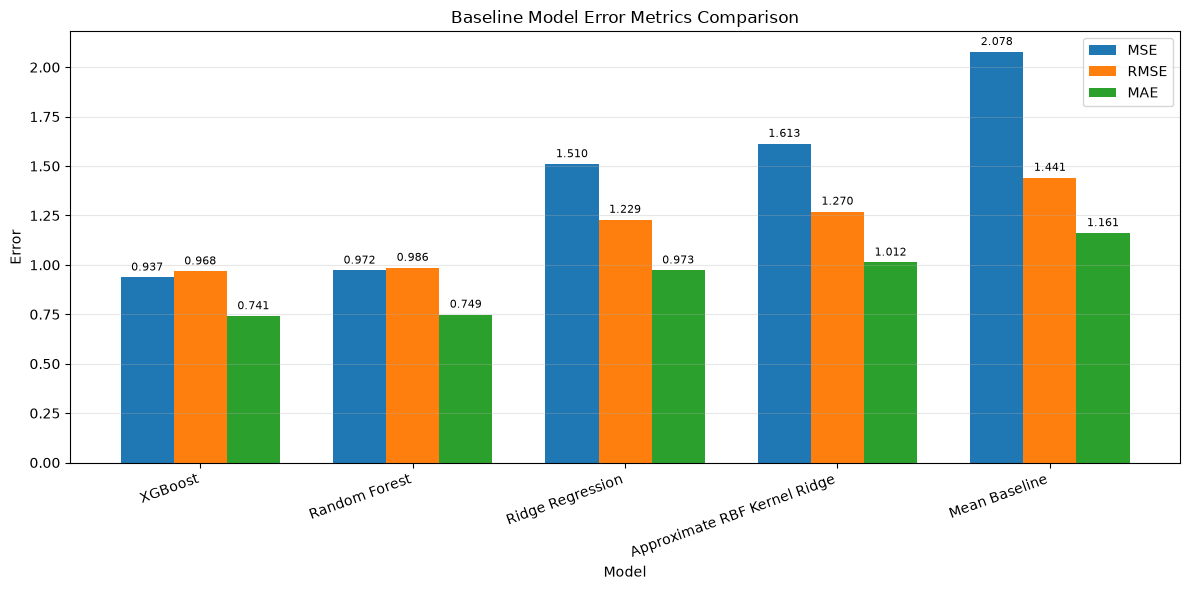

Saved: results/plots/baseline_error_metrics.png


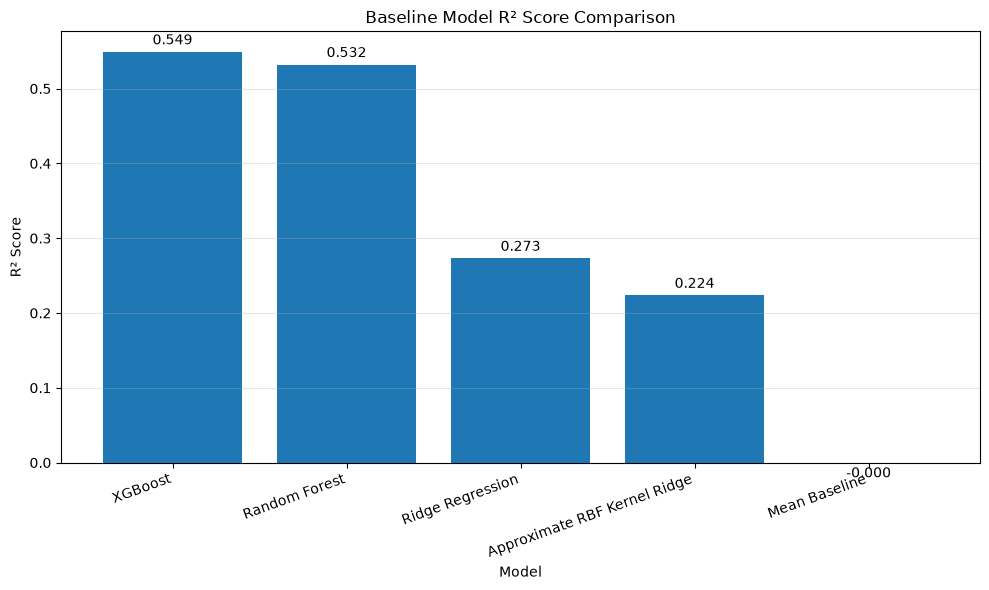

Saved: results/plots/baseline_r2_scores.png


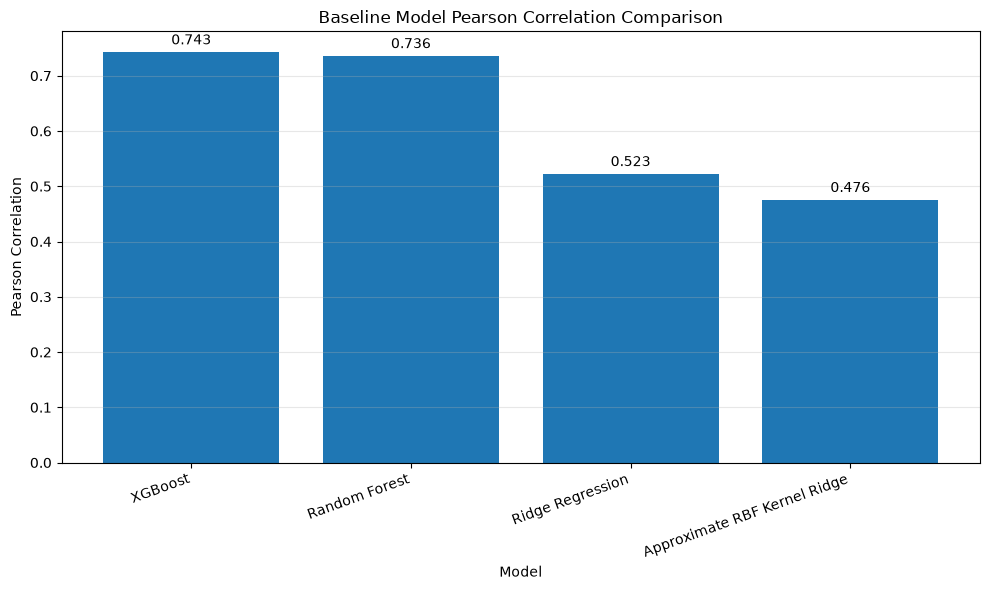

Saved: results/plots/baseline_pearson_correlation.png


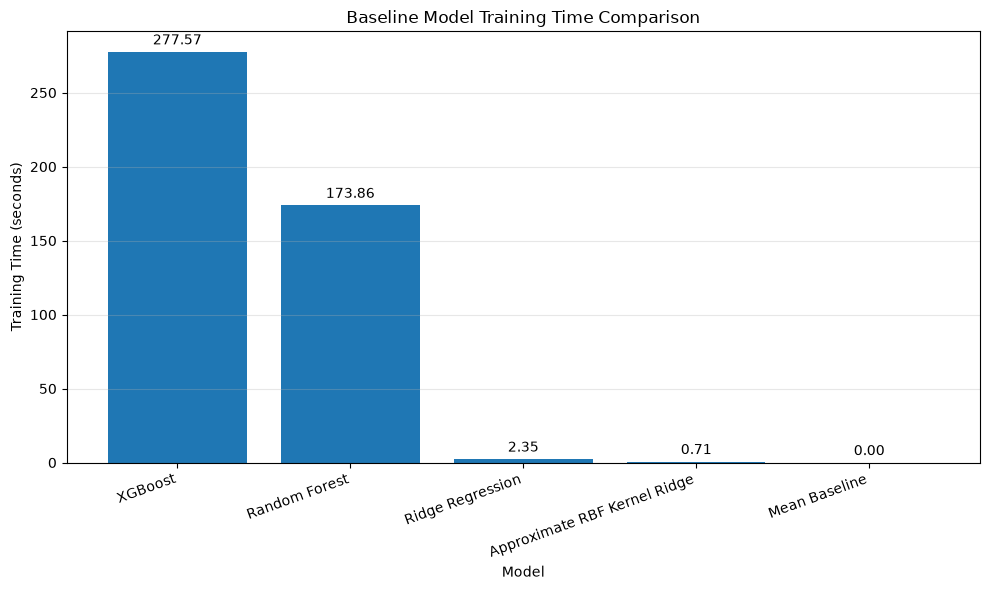

Saved: results/plots/baseline_training_time.png


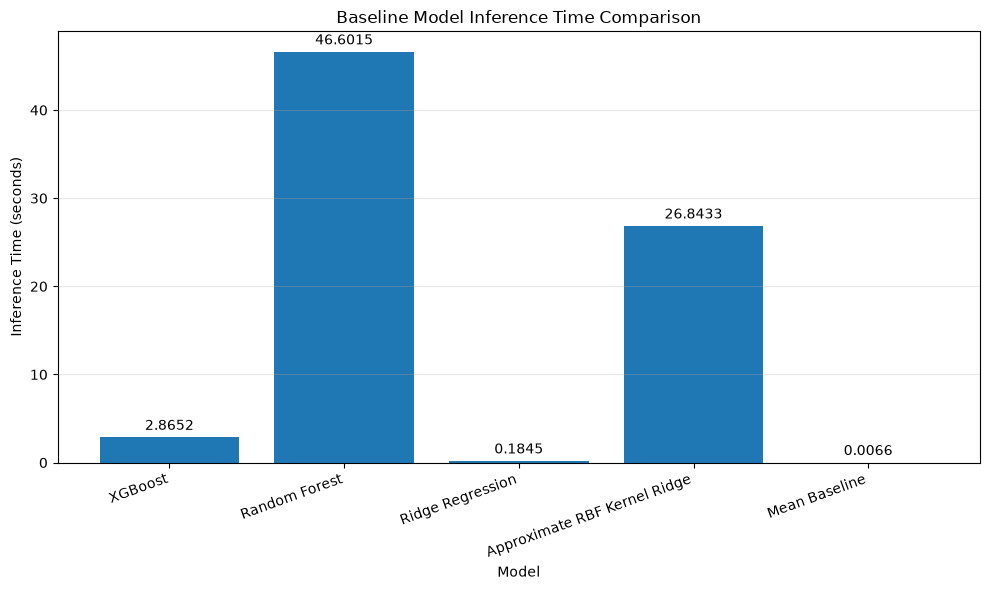

Saved: results/plots/baseline_inference_time.png


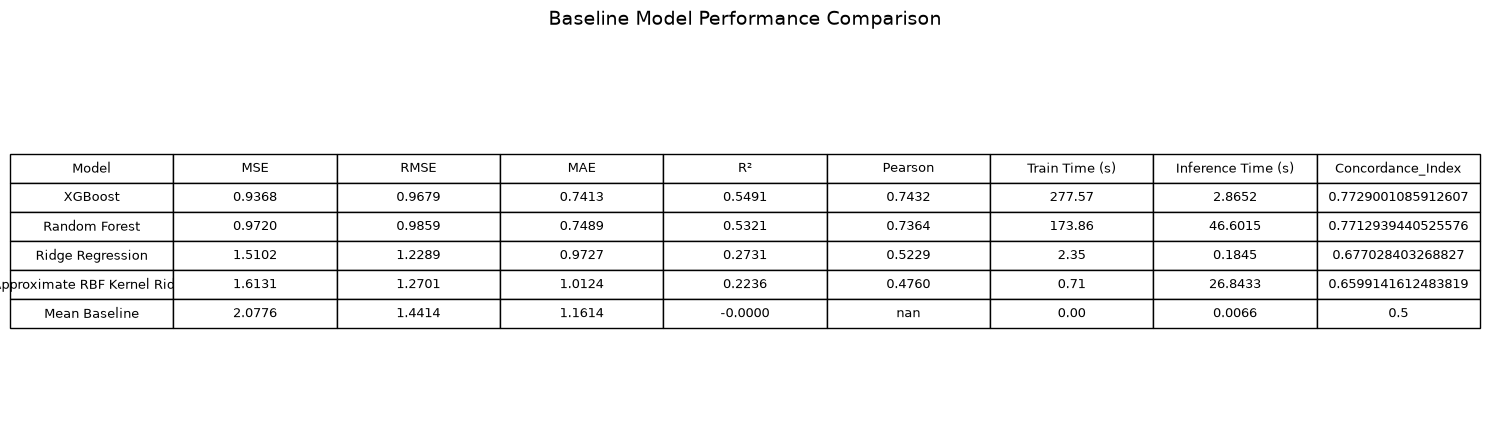

Saved: results/plots/baseline_results_table.png


In [30]:
# ============================================================
# MAIN EXPERIMENTAL EXECUTION
# ============================================================

if __name__ == "__main__":

    # ========================================================
    # 0. EXPERIMENT VALIDATION
    # ========================================================

    print("=" * 70)
    print("DRUG-TARGET AFFINITY BASELINE EXPERIMENT")
    print("=" * 70)

    evaluator = ModelEvaluator()

    # --------------------------------------------------------
    # Verify feature/target alignment
    # --------------------------------------------------------

    assert len(X_train_ml) == len(y_train)
    assert len(X_val_ml) == len(y_val)
    assert len(X_test_ml) == len(y_test)

    assert X_train_ml.shape[1] == X_val_ml.shape[1]
    assert X_train_ml.shape[1] == X_test_ml.shape[1]

    assert np.isfinite(y_train).all()
    assert np.isfinite(y_val).all()
    assert np.isfinite(y_test).all()

    print("\nDataset partitions")
    print("-" * 40)
    print(f"Train      : {len(y_train):,}")
    print(f"Validation : {len(y_val):,}")
    print(f"Test       : {len(y_test):,}")
    print(f"Features   : {X_train_ml.shape[1]:,}")

    number_of_features = X_train_ml.shape[1]

    # Keep a copy of the test target for later verification
    fixed_y_test = np.asarray(y_test).ravel().copy()

    # Store predictions for later plotting/statistical testing
    prediction_results = {
        "Experimental_pKi": fixed_y_test
    }

    # ========================================================
    # 1. NAÏVE MEAN BASELINE
    # ========================================================

    print("\n" + "=" * 70)
    print("1. Mean Baseline")
    print("=" * 70)

    dummy_model = DummyRegressor(
        strategy="mean"
    )

    dummy_model = train_and_evaluate(
        model=dummy_model,
        model_name="Mean Baseline",
        X_train=X_train_ml,
        y_train=y_train,
        X_test=X_test_ml,
        y_test=fixed_y_test,
        evaluator=evaluator
    )

    dummy_predictions = dummy_model.predict(
        X_test_ml
    )

    prediction_results[
        "Mean_Baseline"
    ] = np.asarray(dummy_predictions).ravel()


    # ========================================================
    # 2. RIDGE REGRESSION
    # ========================================================
    #
    # Select alpha using VALIDATION data.
    # Test data are not inspected.
    # ========================================================

    print("\n" + "=" * 70)
    print("2. Ridge Regression")
    print("=" * 70)

    ridge_alphas = [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]

    best_ridge_alpha = None
    best_ridge_rmse = np.inf

    print("\nSelecting Ridge alpha using validation set...")

    for alpha in ridge_alphas:

        ridge_candidate = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "ridge",
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                    max_iter=10_000,
                    tol=1e-4
                )
            )
        ])

        ridge_candidate.fit(
            X_train_ml,
            y_train
        )

        val_predictions = ridge_candidate.predict(
            X_val_ml
        )

        val_rmse = np.sqrt(
            mean_squared_error(
                y_val,
                val_predictions
            )
        )

        print(
            f"alpha={alpha:<7} "
            f"Validation RMSE={val_rmse:.4f}"
        )

        if val_rmse < best_ridge_rmse:

            best_ridge_rmse = val_rmse
            best_ridge_alpha = alpha


    print(
        f"\nBest Ridge alpha: "
        f"{best_ridge_alpha}"
    )

    print(
        f"Best validation RMSE: "
        f"{best_ridge_rmse:.4f}"
    )


    # --------------------------------------------------------
    # Train selected Ridge model
    # --------------------------------------------------------

    ridge_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(
                alpha=best_ridge_alpha,
                solver="lsqr",
                max_iter=10_000,
                tol=1e-4
            )
        )
    ])

    ridge_pipeline = train_and_evaluate(
        model=ridge_pipeline,
        model_name="Ridge Regression",
        X_train=X_train_ml,
        y_train=y_train,
        X_test=X_test_ml,
        y_test=fixed_y_test,
        evaluator=evaluator
    )

    ridge_predictions = ridge_pipeline.predict(
        X_test_ml
    )

    prediction_results[
        "Ridge_Regression"
    ] = np.asarray(ridge_predictions).ravel()


    # ========================================================
    # 3. RANDOM FOREST
    # ========================================================
    #
    # Use validation set for a small, controlled
    # hyperparameter search.
    #
    # Avoid a huge grid because RF is expensive for this
    # dataset.
    # ========================================================

    print("\n" + "=" * 70)
    print("3. Random Forest")
    print("=" * 70)

    rf_candidates = [

        {
            "max_depth": 12,
            "min_samples_leaf": 2,
            "max_features": 0.20
        },

        {
            "max_depth": 16,
            "min_samples_leaf": 2,
            "max_features": 0.20
        },

        {
            "max_depth": 20,
            "min_samples_leaf": 2,
            "max_features": 0.30
        },

        {
            "max_depth": None,
            "min_samples_leaf": 3,
            "max_features": 0.20
        }
    ]


    best_rf_params = None
    best_rf_rmse = np.inf

    print(
        "\nSelecting Random Forest parameters "
        "using validation set..."
    )


    for params in rf_candidates:

        rf_candidate = RandomForestRegressor(

            # Smaller forest during parameter selection
            n_estimators=100,

            max_depth=params[
                "max_depth"
            ],

            min_samples_split=4,

            min_samples_leaf=params[
                "min_samples_leaf"
            ],

            max_features=params[
                "max_features"
            ],

            max_samples=0.80,

            bootstrap=True,

            n_jobs=-1,

            random_state=RANDOM_STATE
        )


        rf_candidate.fit(
            X_train_ml,
            y_train
        )


        val_predictions = rf_candidate.predict(
            X_val_ml
        )


        val_rmse = np.sqrt(
            mean_squared_error(
                y_val,
                val_predictions
            )
        )


        print(
            f"{params} "
            f"-> RMSE={val_rmse:.4f}"
        )


        if val_rmse < best_rf_rmse:

            best_rf_rmse = val_rmse
            best_rf_params = params


    print(
        "\nBest RF parameters:",
        best_rf_params
    )

    print(
        f"Best validation RMSE: "
        f"{best_rf_rmse:.4f}"
    )


    # --------------------------------------------------------
    # Train final RF with more trees
    # --------------------------------------------------------

    random_forest_model = RandomForestRegressor(

        n_estimators=300,

        max_depth=best_rf_params[
            "max_depth"
        ],

        min_samples_split=4,

        min_samples_leaf=best_rf_params[
            "min_samples_leaf"
        ],

        max_features=best_rf_params[
            "max_features"
        ],

        max_samples=0.80,

        bootstrap=True,

        n_jobs=-1,

        random_state=RANDOM_STATE
    )


    random_forest_model = train_and_evaluate(

        model=random_forest_model,

        model_name="Random Forest",

        X_train=X_train_ml,

        y_train=y_train,

        X_test=X_test_ml,

        y_test=fixed_y_test,

        evaluator=evaluator
    )


    rf_predictions = random_forest_model.predict(
        X_test_ml
    )

    prediction_results[
        "Random_Forest"
    ] = np.asarray(rf_predictions).ravel()


    # ========================================================
    # 4. XGBOOST
    # ========================================================
    #
    # Validation is used for early stopping.
    #
    # The test dataset remains completely untouched.
    # ========================================================

    print("\n" + "=" * 70)
    print("4. XGBoost")
    print("=" * 70)

    xgb_model = xgb.XGBRegressor(

        objective="reg:squarederror",

        # High maximum number of estimators.
        # Early stopping determines effective number.
        n_estimators=3_000,

        learning_rate=0.03,

        max_depth=6,

        min_child_weight=5,

        subsample=0.80,

        colsample_bytree=0.70,

        reg_alpha=0.05,

        reg_lambda=1.0,

        tree_method="hist",

        max_bin=256,

        early_stopping_rounds=50,

        eval_metric="rmse",

        n_jobs=-1,

        random_state=RANDOM_STATE
    )


    print("\nTraining XGBoost...")

    start_time = time.perf_counter()


    xgb_model.fit(

        X_train_ml,

        y_train,

        eval_set=[
            (
                X_val_ml,
                y_val
            )
        ],

        verbose=False
    )


    xgb_train_time = (
        time.perf_counter()
        - start_time
    )


    # --------------------------------------------------------
    # Test inference
    # --------------------------------------------------------

    start_time = time.perf_counter()


    xgb_predictions = predict_in_batches(
        xgb_model,
        X_test_ml
    )


    xgb_inference_time = (
        time.perf_counter()
        - start_time
    )


    evaluator.evaluate(

        model_name="XGBoost",

        y_true=fixed_y_test,

        y_pred=xgb_predictions,

        train_time=xgb_train_time,

        inference_time=xgb_inference_time
    )


    prediction_results[
        "XGBoost"
    ] = np.asarray(
        xgb_predictions
    ).ravel()


    if (
        hasattr(
            xgb_model,
            "best_iteration"
        )
        and xgb_model.best_iteration
        is not None
    ):

        print(
            f"Best XGBoost iteration: "
            f"{xgb_model.best_iteration}"
        )


    # ========================================================
    # 5. APPROXIMATE RBF KERNEL MODEL
    # ========================================================
    #
    # IMPORTANT:
    #
    # Nystroem + Ridge is NOT technically an SVM.
    #
    # It is better described as:
    #
    # "Approximate RBF Kernel Ridge"
    #
    # ========================================================

    print("\n" + "=" * 70)
    print("5. Approximate RBF Kernel Ridge")
    print("=" * 70)


    # --------------------------------------------------------
    # Select random training subset
    # --------------------------------------------------------

    svm_sample_size = min(
        20_000,
        len(X_train_ml)
    )


    random_generator = np.random.default_rng(
        RANDOM_STATE
    )


    kernel_indices = random_generator.choice(

        len(X_train_ml),

        size=svm_sample_size,

        replace=False
    )


    X_train_kernel = X_train_ml[
        kernel_indices
    ]

    y_train_kernel = y_train[
        kernel_indices
    ]


    # --------------------------------------------------------
    # Initial RBF gamma
    #
    # Using 1 / number_of_features is a reasonable
    # scale-aware starting point.
    # --------------------------------------------------------

    base_gamma = (
        1.0
        / number_of_features
    )


    gamma_candidates = [

        base_gamma * 0.1,

        base_gamma,

        base_gamma * 10
    ]


    best_gamma = None
    best_kernel_rmse = np.inf


    print(
        "\nSelecting RBF gamma using validation set..."
    )


    for gamma in gamma_candidates:

        kernel_candidate = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "nystroem",
                Nystroem(
                    kernel="rbf",
                    gamma=gamma,
                    n_components=1000,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            ),
            (
                "ridge",
                Ridge(
                    alpha=1.0,
                    solver="lsqr",
                    max_iter=5000,
                    tol=1e-3
                )
            )
        ])


        kernel_candidate.fit(
            X_train_kernel,
            y_train_kernel
        )


        val_predictions = kernel_candidate.predict(
            X_val_ml
        )


        val_rmse = np.sqrt(
            mean_squared_error(
                y_val,
                val_predictions
            )
        )


        print(
            f"gamma={gamma:.8f} "
            f"Validation RMSE={val_rmse:.4f}"
        )


        if val_rmse < best_kernel_rmse:

            best_kernel_rmse = val_rmse
            best_gamma = gamma


    print(
        f"\nBest gamma: {best_gamma:.8f}"
    )

    print(
        f"Best validation RMSE: "
        f"{best_kernel_rmse:.4f}"
    )


    # --------------------------------------------------------
    # Final Approximate Kernel Ridge
    # --------------------------------------------------------

    kernel_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "nystroem",
            Nystroem(
                kernel="rbf",
                gamma=best_gamma,
                n_components=1_000,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
        (
            "ridge",
            Ridge(
                alpha=1.0,
                solver="lsqr",
                max_iter=5_000,
                tol=1e-3
            )
        )
    ])


    kernel_pipeline = train_and_evaluate(

        model=kernel_pipeline,

        model_name=(
            "Approximate RBF Kernel Ridge"
        ),

        X_train=X_train_kernel,

        y_train=y_train_kernel,

        X_test=X_test_ml,

        y_test=fixed_y_test,

        evaluator=evaluator
    )


    kernel_predictions = (
        kernel_pipeline.predict(
            X_test_ml
        )
    )


    prediction_results[
        "Approx_RBF_Kernel_Ridge"
    ] = np.asarray(
        kernel_predictions
    ).ravel()


    # Release temporary arrays

    del X_train_kernel
    del y_train_kernel
    del kernel_indices


    # ========================================================
    # 6. VERIFY COMMON TEST SET
    # ========================================================

    print("\n" + "=" * 70)
    print("TEST-SET CONSISTENCY CHECK")
    print("=" * 70)


    for model_name, predictions \
            in prediction_results.items():

        if model_name == "Experimental_pKi":
            continue

        assert (
            len(predictions)
            ==
            len(fixed_y_test)
        ), (
            f"{model_name} predictions "
            "do not match test-set size."
        )


        assert np.isfinite(
            predictions
        ).all(), (
            f"{model_name} contains "
            "invalid predictions."
        )


        print(
            f"{model_name:<30} "
            f"{len(predictions):>8,} predictions ✓"
        )


    print(
        "\nAll models evaluated on the "
        "same fixed test observations."
    )


    # ========================================================
    # 7. SAVE INDIVIDUAL TEST PREDICTIONS
    # ========================================================

    os.makedirs(
        "results",
        exist_ok=True
    )


    predictions_df = pd.DataFrame(
        prediction_results
    )


    predictions_df.to_csv(

        "results/"
        "baseline_test_predictions.csv",

        index=False
    )


    print(
        "\nSaved predictions to:"
        "\nresults/"
        "baseline_test_predictions.csv"
    )


    # ========================================================
    # 8. FINAL MODEL COMPARISON
    # ========================================================

    evaluator.print_summary()

    evaluator.save_to_csv(
        RESULTS_FILE
    )

    evaluator.generate_report()